In [79]:
from framework import (
    EpsilonGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [80]:
FPA_baseline = pd.read_csv("Results_FPA/Initial results/FPA_auction_summary_results.csv")
SPA_baseline = pd.read_csv("Results_FPA/Initial results/SPA_auction_summary_results.csv")

In [ ]:
FPA_stochastic = []
df = pd.read_csv("Results_FPA/Stochastic/FPA_value_0.5.csv")
FPA_stochastic.append(df)
shocks = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,]
for i in range(1, len(shocks)):
    df = pd.read_csv(f"Results_FPA/Stochastic/equal_shocks/FPA_stochastic_both_{shocks[i]}.csv")
    FPA_stochastic.append(df)

del df


In [103]:
def plot_bid_heatmap(df, title=None):

    df = df.dropna(subset=["rounds_to_convergence"])

    bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

    heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

    for b1, b2 in zip(df["converged_bid_Agent1"], df["converged_bid_Agent2"]):
        heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

    heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

    heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

    plt.figure(figsize=(10, 7))
    sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
    plt.xlabel("Agent 1 Converged Bid")
    plt.ylabel("Agent 2 Converged Bid")
    plt.tight_layout()
    plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

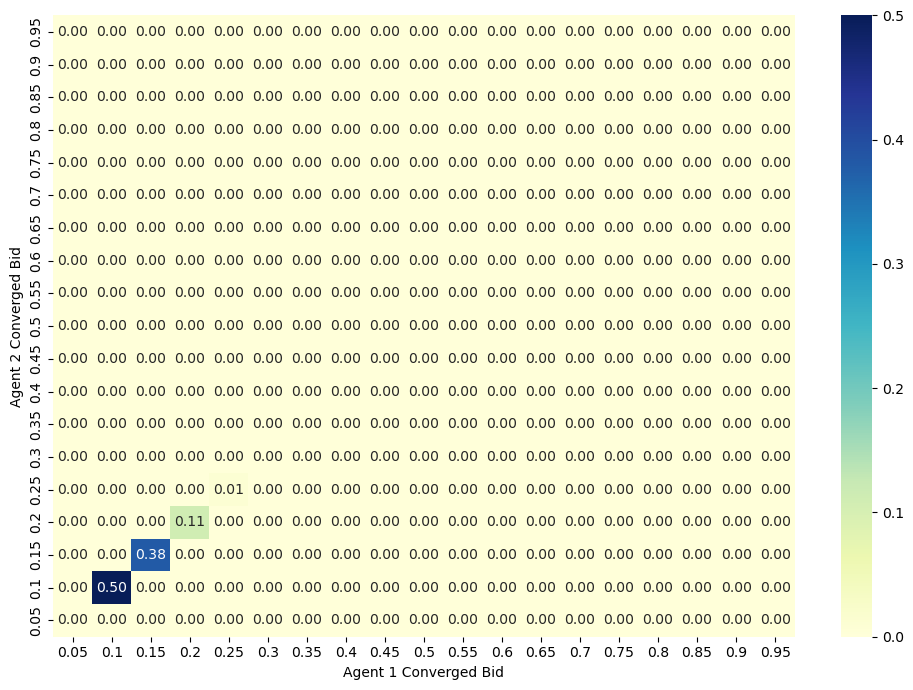

In [83]:
plot_bid_heatmap(FPA_stochastic[0], title="FPA_heatmap_value_0.5")

In [84]:
print(f"In the FPA the mean bid converged to is: ", FPA_stochastic[0]["converged_bid_Agent1"].mean())

In the FPA the mean bid converged to is:  0.13149999999999998


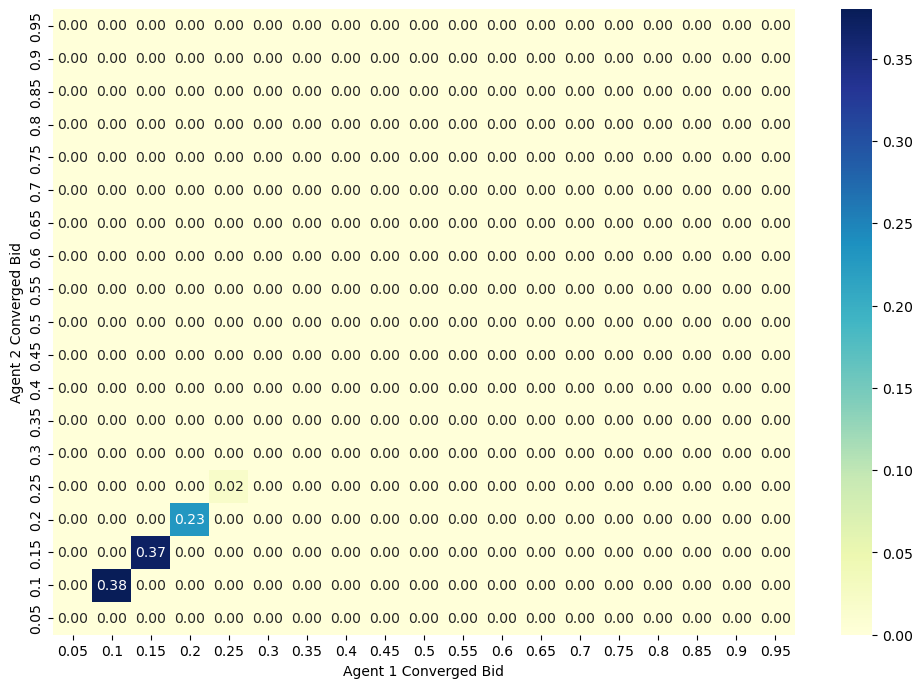

In [101]:
plot_bid_heatmap(FPA_stochastic[4], "FPA_stochastic_0.2")

Even for $\delta = 0.5$ the bidders still converge on a low-bidding outcome, evidence of robustness of the tacit-collusive mechanism in the face of stochastic values.

In [86]:
baseline_mean = FPA_baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(FPA_stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    print(f"s = {shocks[i]}: {converged_bid_mean}")

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
s = 0: 0.13149999999999998
s = 0.05: 0.1365
s = 0.1: 0.13799999999999998
s = 0.15: 0.14449999999999996
s = 0.2: 0.1445
s = 0.25: 0.13599999999999998
s = 0.3: 0.14399999999999996
s = 0.35: 0.15
s = 0.4: 0.15
s = 0.45: 0.1545
s = 0.5: 0.15


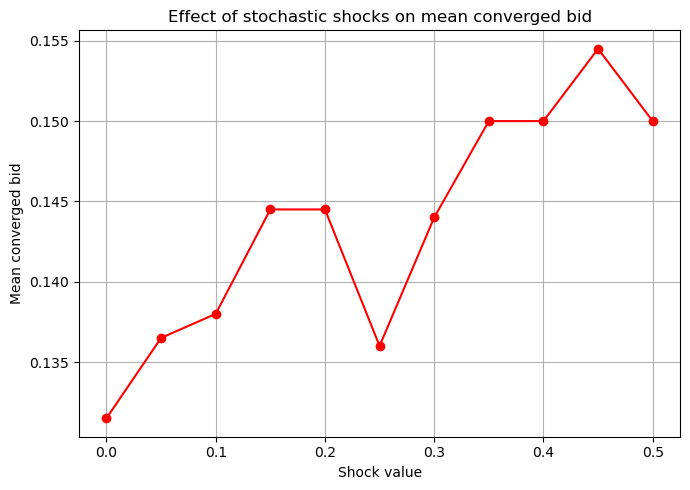

Pearson correlation: 0.874 (p = 0.00043)


In [87]:
from scipy.stats import pearsonr

# --- compute mean converged bid for each shock ---
stochastic_means = []
for i, df in enumerate(FPA_stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    stochastic_means.append(converged_bid_mean)

# --- plot shocks vs mean converged bid ---
plt.figure(figsize=(7,5))
plt.plot(shocks, stochastic_means, marker="o", linestyle="-", color="red")
plt.xlabel("Shock value")
plt.ylabel("Mean converged bid")
plt.title("Effect of stochastic shocks on mean converged bid")
plt.grid(True)
plt.tight_layout()
#plt.savefig(f"FPA_stochastic_delta_corr.pdf", format="pdf", bbox_inches="tight")
plt.show()

# --- Pearson correlation ---
corr, pval = pearsonr(shocks, stochastic_means)
print(f"Pearson correlation: {corr:.3f} (p = {pval:.3g})")

In [88]:
SPA_stochastic = []
df = pd.read_csv("Results_SPA/SPA_value_0.5.csv")
SPA_stochastic.append(df)
shocks = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
for i in range(1, len(shocks)):
    df = pd.read_csv(f"Results_SPA/Stochastic/SPA_stochastic_both_{shocks[i]}.csv")
    SPA_stochastic.append(df)

del df

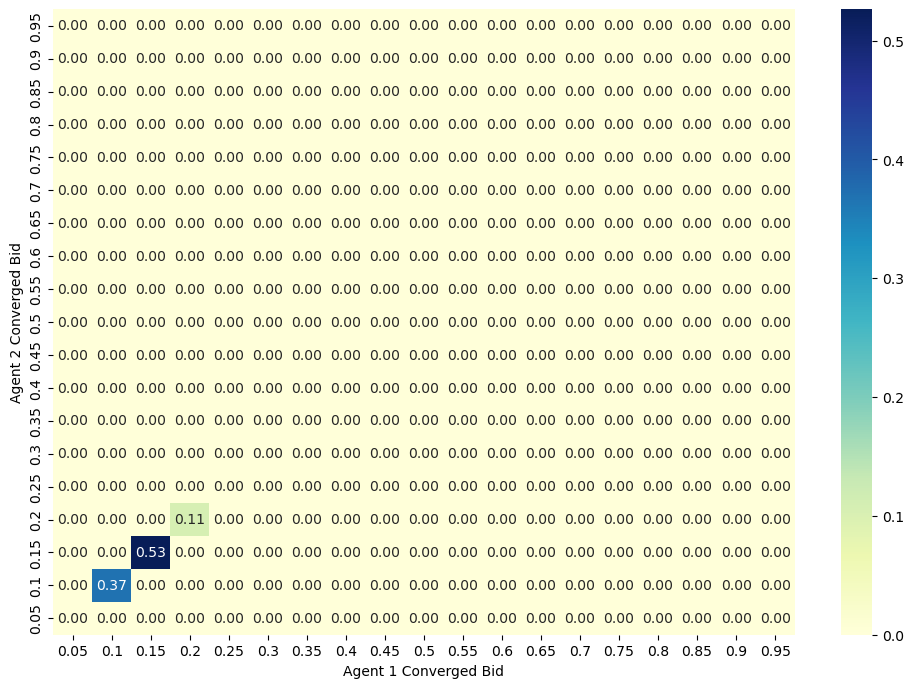

In [104]:
plot_bid_heatmap(SPA_stochastic[4], title="SPA_heatmap_value_0.2")

In [90]:
cleaned_SPA_05 = SPA_stochastic[0].dropna(subset=["rounds_to_convergence"])
print(f"In the SPA the mean bid converged to is: ", cleaned_SPA_05["converged_bid_Agent1"].mean())

In the SPA the mean bid converged to is:  0.11363636363636363


In [97]:
print(f"Percentage of simulations converging to collusive equilibria in the SPA was: ", (len(cleaned_SPA_05)*100)/len(SPA_stochastic[0]), "%")

for i, df in enumerate(SPA_stochastic):
    cleaned_df = df.dropna(subset=["rounds_to_convergence"])
    print(f"Percentage of simulations converging to collusive equilibria with delta = {shocks[i]} was: {(len(cleaned_df)*100)/len(df)}")

Percentage of simulations converging to collusive equilibria in the SPA was:  22.0 %
Percentage of simulations converging to collusive equilibria with delta = 0 was: 22.0
Percentage of simulations converging to collusive equilibria with delta = 0.05 was: 19.0
Percentage of simulations converging to collusive equilibria with delta = 0.1 was: 23.0
Percentage of simulations converging to collusive equilibria with delta = 0.15 was: 15.0
Percentage of simulations converging to collusive equilibria with delta = 0.2 was: 19.0
Percentage of simulations converging to collusive equilibria with delta = 0.25 was: 21.0
Percentage of simulations converging to collusive equilibria with delta = 0.3 was: 10.0
Percentage of simulations converging to collusive equilibria with delta = 0.35 was: 11.0
Percentage of simulations converging to collusive equilibria with delta = 0.4 was: 5.0
Percentage of simulations converging to collusive equilibria with delta = 0.45 was: 25.0
Percentage of simulations converg

In [99]:
SPA_baseline_mean = SPA_baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(SPA_stochastic):
    clean_df = df.dropna(subset=["rounds_to_convergence"])
    
    converged_bid_mean = clean_df["converged_bid_Agent1"].mean()
    print(f"delta = {shocks[i]}: {converged_bid_mean}")

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
delta = 0: 0.11363636363636363
delta = 0.05: 0.1236842105263158
delta = 0.1: 0.11086956521739133
delta = 0.15: 0.11333333333333336
delta = 0.2: 0.1368421052631579
delta = 0.25: 0.11428571428571428
delta = 0.3: 0.12
delta = 0.35: 0.17727272727272728
delta = 0.4: 0.10999999999999999
delta = 0.45: 0.12
delta = 0.5: 0.11578947368421054


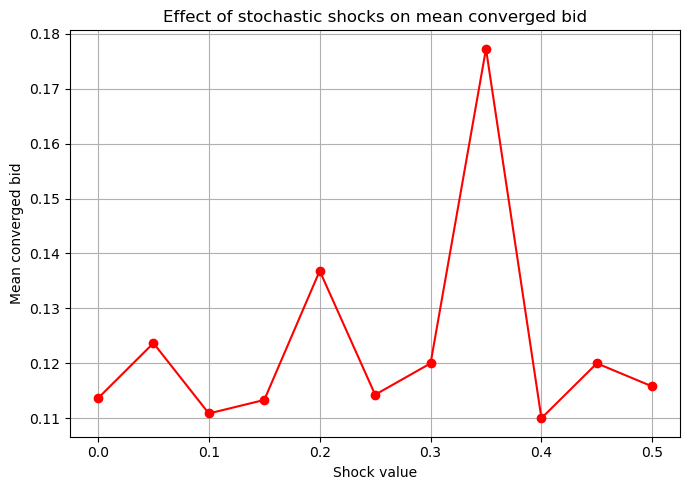

Pearson correlation: 0.162 (p = 0.634)


In [100]:
# --- compute mean converged bid for each shock ---
stochastic_means = []
for i, df in enumerate(SPA_stochastic):
    clean_df = df.dropna(subset=["rounds_to_convergence"])
    converged_bid_mean = clean_df["converged_bid_Agent1"].mean()
    stochastic_means.append(converged_bid_mean)

# --- plot shocks vs mean converged bid ---
plt.figure(figsize=(7,5))
plt.plot(shocks, stochastic_means, marker="o", linestyle="-", color="red")
plt.xlabel("Shock value")
plt.ylabel("Mean converged bid")
plt.title("Effect of stochastic shocks on mean converged bid")
plt.grid(True)
plt.tight_layout()
#plt.savefig(f"SPA_stochastic_delta_corr.pdf", format="pdf", bbox_inches="tight")
plt.show()

# --- Pearson correlation ---
corr, pval = pearsonr(shocks, stochastic_means)
print(f"Pearson correlation: {corr:.3f} (p = {pval:.3g})")

In [92]:
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

history_01 = simulation.run()

Convergence detected after 254249 rounds.
Bidder Agent1 converged to bid 0.95.
Bidder Agent2 converged to bid 0.95.


In [93]:
history_01[0]

({<framework.EpsilonGreedy at 0x331e49a10>: np.float64(0.15000000000000002),
  <framework.EpsilonGreedy at 0x319e7ec10>: np.float64(0.15000000000000002)},
 'Agent2',
 np.float64(0.15000000000000002),
 {<framework.EpsilonGreedy at 0x331e49a10>: 0.0,
  <framework.EpsilonGreedy at 0x319e7ec10>: 0.85},
 {'Agent1': array([100.  , 100.  ,  99.95, 100.  , 100.  , 100.  , 100.  , 100.  ,
         100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  ,
         100.  , 100.  , 100.  ]),
  'Agent2': array([100.    , 100.    ,  99.9925, 100.    , 100.    , 100.    ,
         100.    , 100.    , 100.    , 100.    , 100.    , 100.    ,
         100.    , 100.    , 100.    , 100.    , 100.    , 100.    ,
         100.    ])})

In [94]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

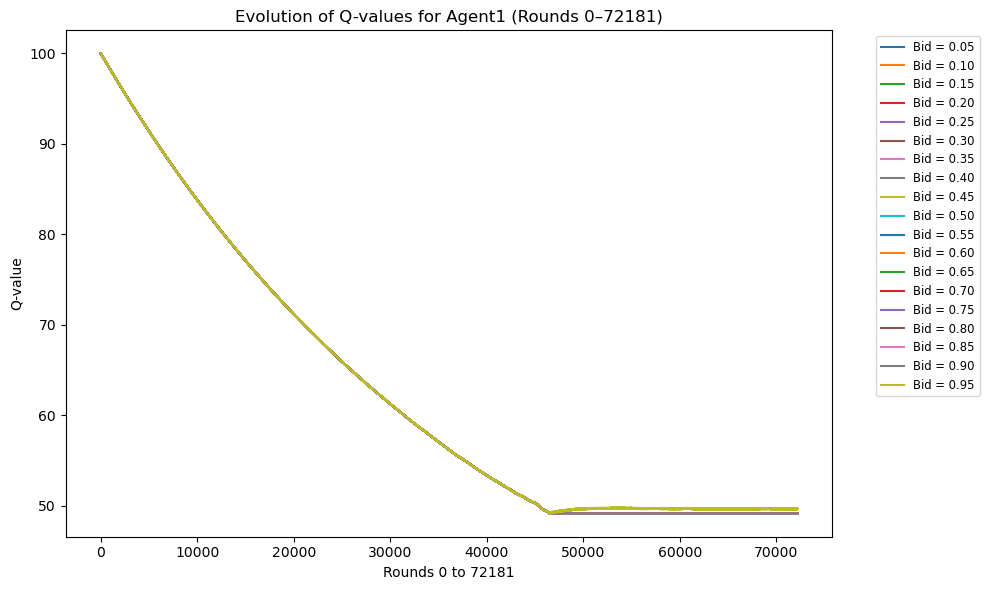

In [95]:
def plot_q_evolution_range(history, bidder_name, start_round, end_round):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

plot_q_evolution_range(history_01, "Agent1", 0, 72181)

Second-price auctions.

In [96]:
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

SPA_history_01 = simulation.run()

TypeError: EpsilonGreedy.__init__() got an unexpected keyword argument 'stochastic'

In [ ]:
stochastic_01 = pd.read_csv("Results_SPA/Stochastic/SPA_stochastic_both_0.1.csv")

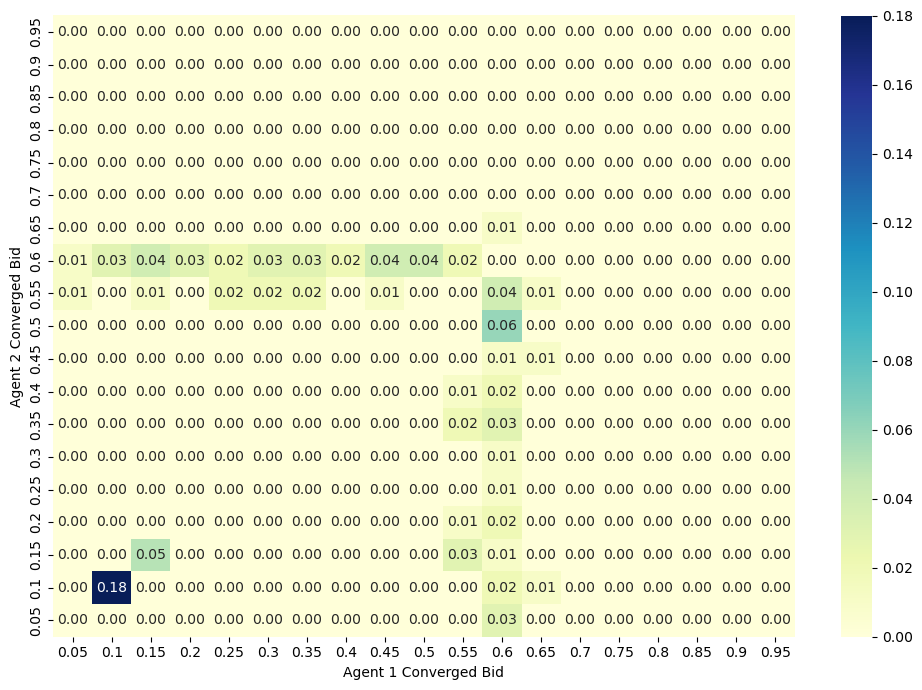

In [ ]:
plot_bid_heatmap(stochastic_01, "SPA_stochastic_0.1")

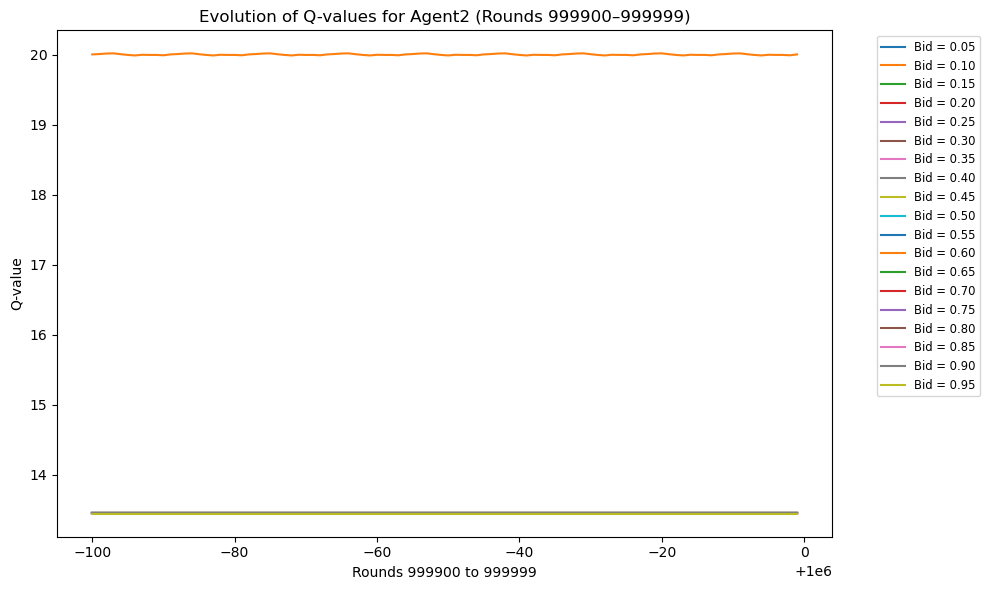

In [ ]:
plot_q_evolution_range(SPA_history_01, "Agent2", 999900, 999999)

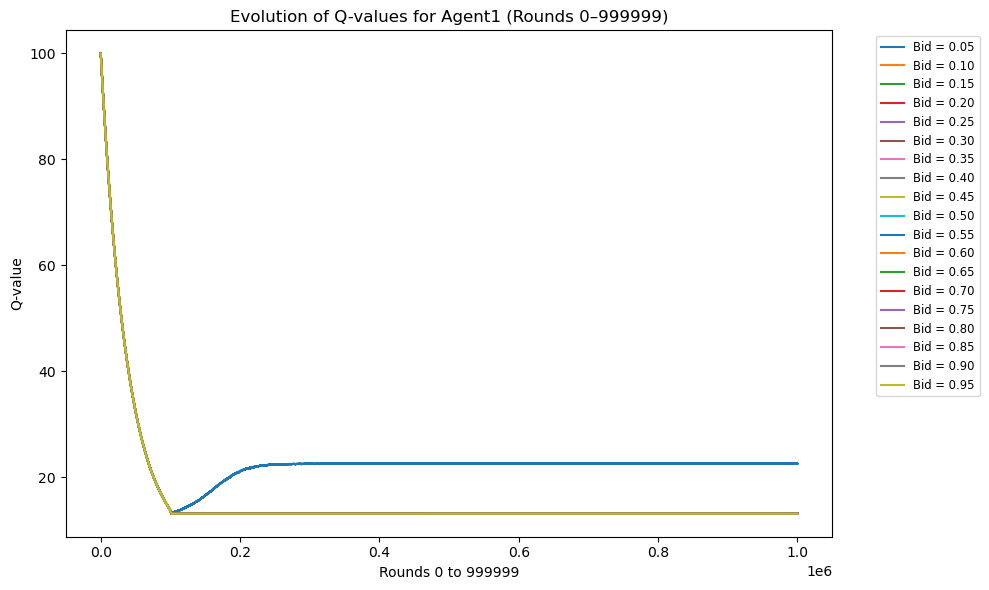

In [ ]:
plot_q_evolution_range(SPA_history_01, "Agent1", 0, 999999)

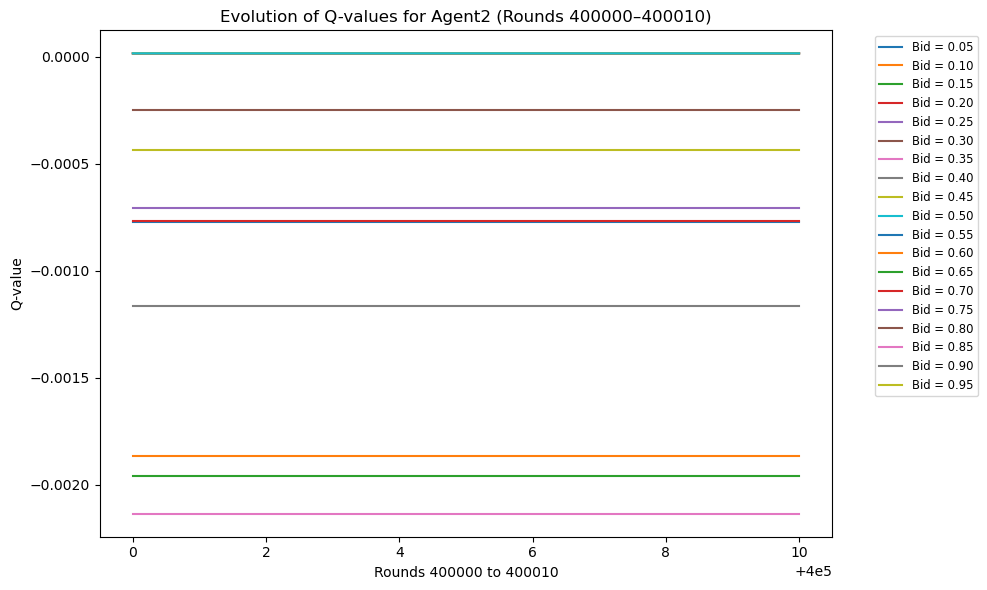

In [ ]:
plot_q_evolution_range(SPA_history_01, "Agent2", 400000, 400010)

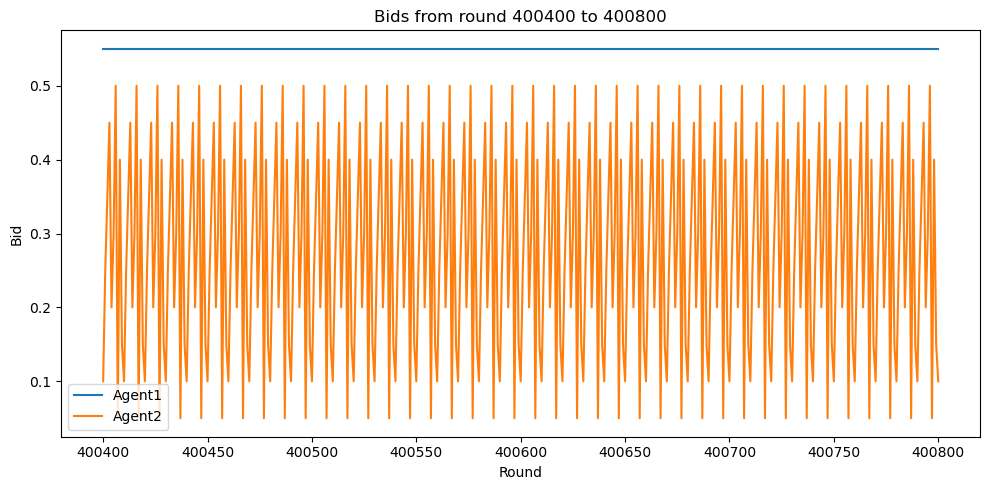

In [ ]:
def plot_bids_interval(history, x, y):

    """
    Plot the bids of both agents between rounds x and y (inclusive).

    Parameters
    ----------
    history : list of tuples
        Each element like (bids_dict, winner, winning_bid, reward, q_snapshot).
    x, y : int
        Start and end rounds (0-based indices).
    """
    rounds = list(range(x, y + 1))

    agent_names = []
    # Collect bid series for each agent
    bid_series = {}

    for t in rounds:
        bids_dict = history[t][0]   # first element = {bidder_obj: bid}
        # On first iteration, record agent names
        if not agent_names:
            agent_names = [bidder.name for bidder in bids_dict.keys()]
            bid_series = {name: [] for name in agent_names}
        # Append bid values for each agent
        for bidder, bid in bids_dict.items():
            bid_series[bidder.name].append(float(bid))

    # Plot
    plt.figure(figsize=(10, 5))
    for name in agent_names:
        plt.plot(rounds, bid_series[name], label=name)

    plt.xlabel("Round")
    plt.ylabel("Bid")
    plt.title(f"Bids from round {x} to {y}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_bids_interval(SPA_history_01, 400400, 400800)

In [ ]:
FPA_2stochastic = []
FPA_1stochastic = []
for i in range(9):
    df2 = pd.read_csv(f"Results_FPA/Stochastic/FPA_stochastic_0_{i+1}_results.csv")
    df1 = pd.read_csv(f"Results_FPA/Stochastic/FPA_stochastic_0_{i+1}_asym_results.csv")
    FPA_2stochastic.append(df2)
    FPA_1stochastic.append(df1)

In [ ]:
FPA_2stochastic[0].head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,75578,0.30,28.948864,0.30,29.158922
1,1,76283,0.20,30.715704,0.20,31.282080
2,2,73628,0.25,31.124464,0.25,29.803906
3,3,72428,0.20,31.202424,0.20,32.256210
4,4,70955,0.10,34.747572,0.10,33.272559


In [ ]:
baseline_mean = baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(FPA_2stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    print(f"s = 0.{i+1}: {converged_bid_mean}")

   

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
s = 0.1: 0.222
s = 0.2: 0.2045
s = 0.3: 0.20450000000000002
s = 0.4: 0.19149999999999998
s = 0.5: 0.18899999999999997
s = 0.6: 0.1805
s = 0.7: 0.16449999999999998
s = 0.8: 0.16999999999999996
s = 0.9: 0.163
The mean bid converged to when agents have stochastic shock s


In [ ]:
baseline_mean = baseline["converged_bid_Agent1"].mean()
print(f"The mean bid converged to for symmetric basiline simulations is {baseline_mean}")

for i, df in enumerate(FPA_1stochastic):
    bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2"]
    df["max_bid_per_sim"] = df[bid_cols].max(axis=1)
    converged_bid_mean = df["max_bid_per_sim"].mean()
    print(f"s = 0.{i+1}: {converged_bid_mean}")

The mean bid converged to for symmetric basiline simulations is 0.22750000000000004
s = 0.1: 0.233
s = 0.2: 0.22
s = 0.3: 0.21000000000000005
s = 0.4: 0.21100000000000002
s = 0.5: 0.206
s = 0.6: 0.218
s = 0.7: 0.23300000000000004
s = 0.8: 0.265
s = 0.9: 0.41450000000000004


In [ ]:
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history_01 = simulation.run()

Convergence detected after 74183 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


In [ ]:
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0.1)

simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

SPA_history_01 = simulation.run()

Agents have not converged after 1,000,000 rounds


In [ ]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

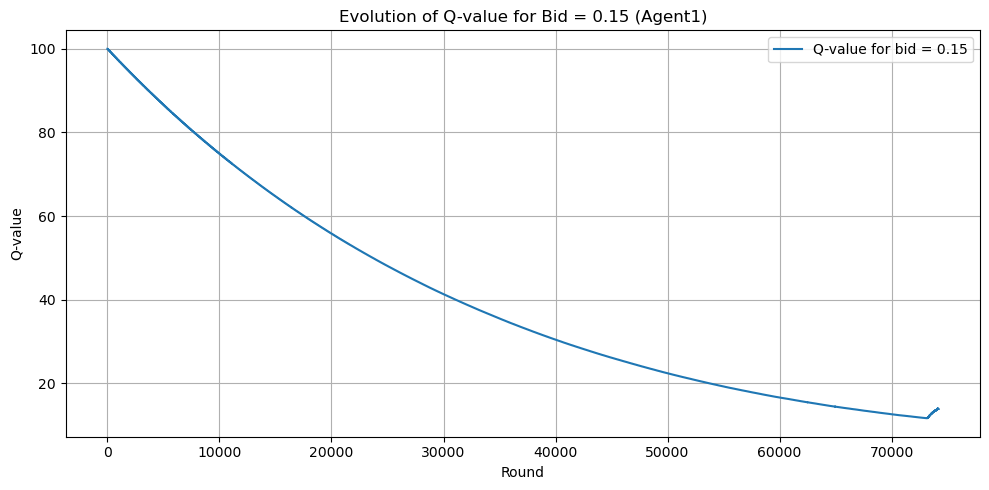

In [ ]:
bidder_name = "Agent1"
bid_index = 1

q_trajectory = extract_q_trajectory(FPA_history_01, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.15")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.15 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

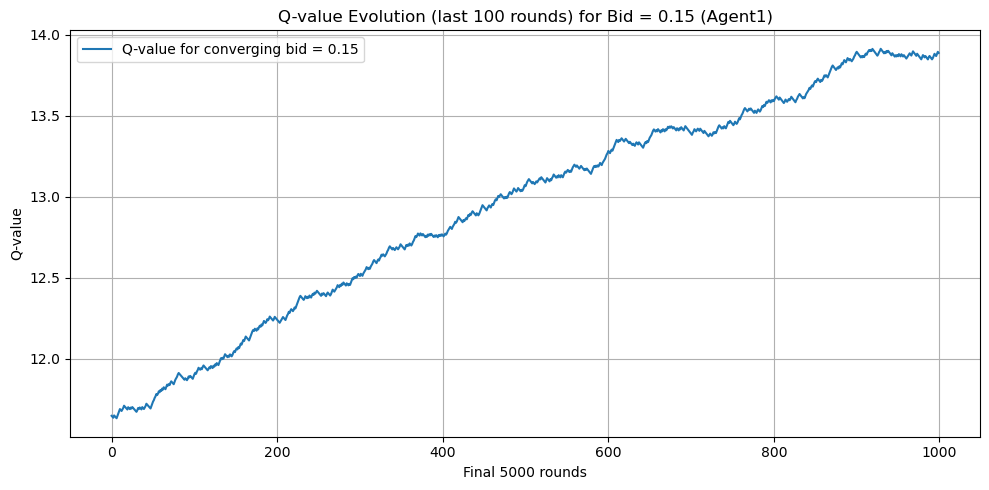

In [ ]:
# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-1000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for converging bid = {0.15}")
plt.xlabel("Final 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 100 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_q_evolution(history, bidder_name, n_last=5000):
    # Only keep the last n_last periods
    hist_tail = history[-n_last:]

    # Define bid grid (matches your environment setup)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot the Q-value trajectory for each bid
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_tail, bidder_name, bid_idx)
        plt.plot(q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds (last {n_last} steps)")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

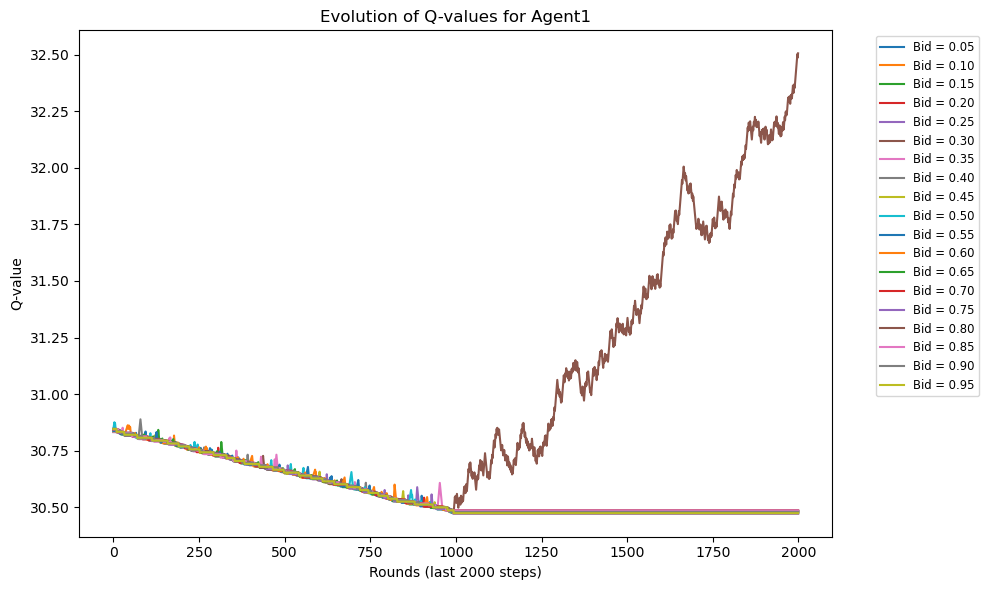

In [ ]:
plot_q_evolution(baseline_history, "Agent1", n_last=2000)

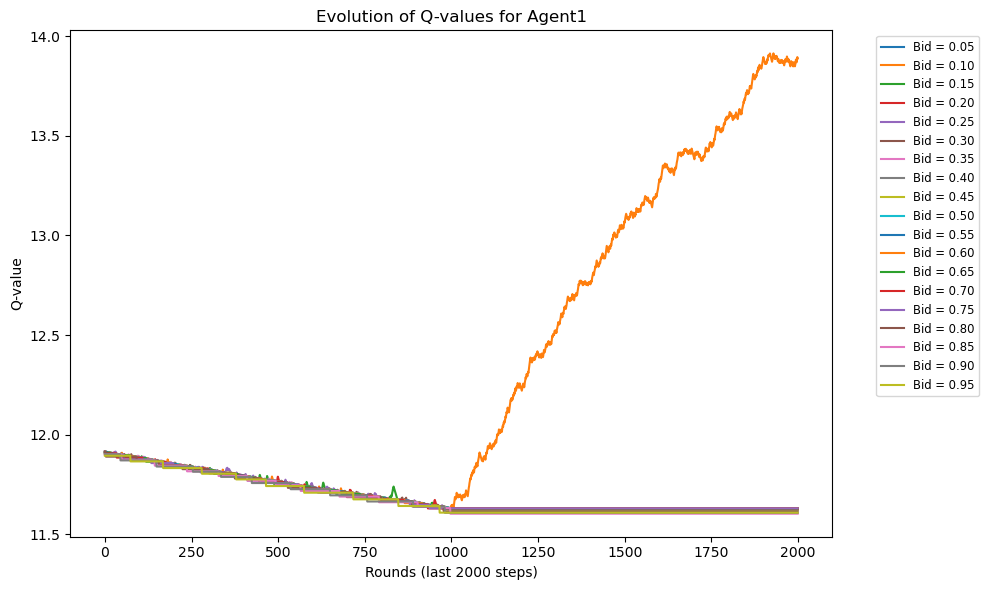

In [ ]:
plot_q_evolution(FPA_history_01, "Agent1", n_last=2000)

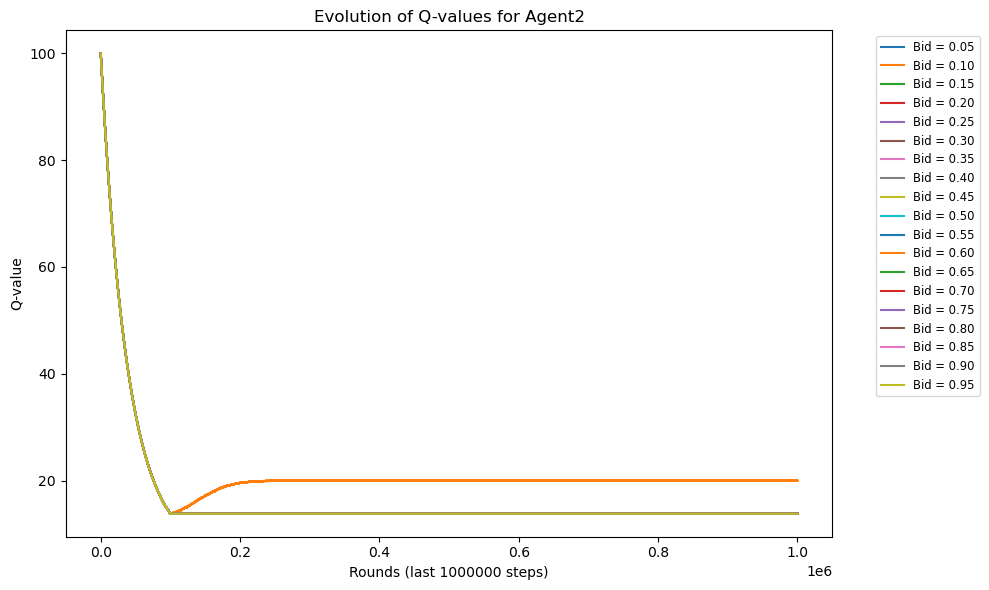

In [ ]:
plot_q_evolution(SPA_history_01, "Agent2", 1000000)

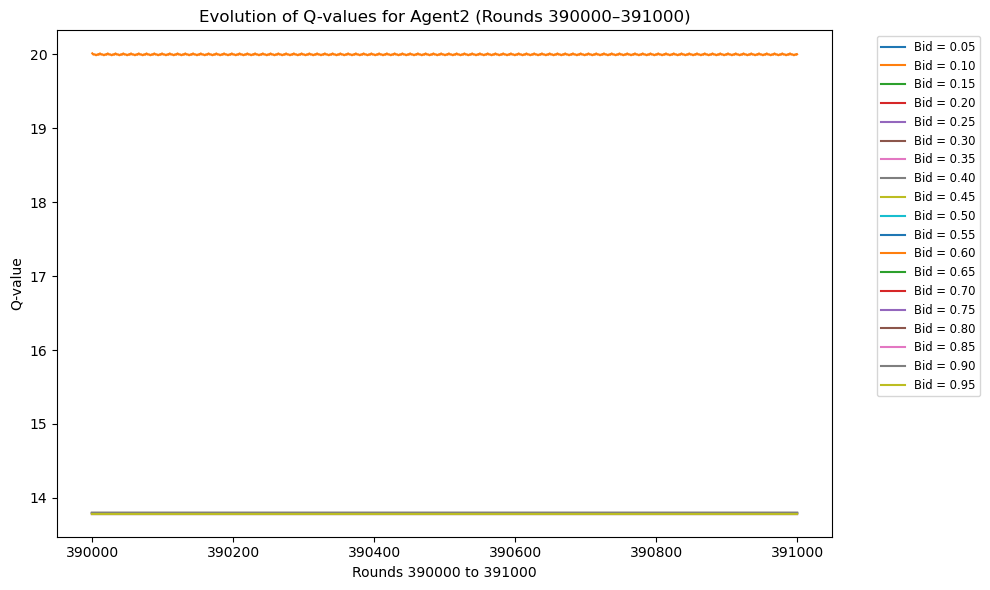

In [ ]:
def plot_q_evolution_range(history, bidder_name, start_round, end_round):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

plot_q_evolution_range(SPA_history_01, "Agent2", 390000, 391000)